# S4 — Détection de régimes de marché : probabiliste + symbolique

**Cours** Intelligence Symbolique (SCIA / EPITA 2026) · **Sujet** S4 · **Membres** Samuel Krief & Nicolas Teisseire

## Le problème
Un **HMM** détecte les régimes de marché (*bull* / *range* / *bear*) numériquement, mais utilisé naïvement il « clignote » (change de régime tous les deux jours) et peut proposer des transitions absurdes (*bull → bear* sans transition). On ajoute deux couches **symboliques** légères pour obtenir un régime plus **stable**, **cohérent** et **interprétable**, puis on l'utilise pour allouer un portefeuille.

## Les trois couches
1. **Probabiliste** — HMM gaussien : `P(régime | observations du jour)`.
2. **Révision des croyances (AGM)** — on ne change de régime *cru* que sur évidence forte et persistante.
3. **Raisonnement qualitatif** — une algèbre de transition interdit les changements de régime incohérents.

→ régime final → **allocation multi-régime** → **backtest** (vs HMM pur, vs buy-and-hold).

> Les données sont téléchargées via `yfinance` si le réseau est disponible, sinon une série **synthétique à régimes connus** est utilisée (reproductible, et permet de mesurer la précision de détection).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from src import data, hmm, agm, qualitative, strategy

REGIMES = ["bear", "range", "bull"]
COLORS = {"bear": "#d64545", "range": "#e0b040", "bull": "#3a9d5d"}

def switches(s): return int((s != s.shift(1)).sum())

def plot_regimes(prices, regimes, title):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(prices.index, prices.values, color="black", lw=1)
    r = regimes.reindex(prices.index).ffill()
    for name in REGIMES:
        ax.fill_between(prices.index, prices.min(), prices.max(),
                        where=(r == name).values, color=COLORS[name], alpha=0.18, step="mid")
    ax.set_title(title); ax.set_ylabel("prix")
    handles = [plt.Rectangle((0,0),1,1,color=COLORS[n],alpha=0.4) for n in REGIMES]
    ax.legend(handles, REGIMES, loc="upper left", ncol=3)
    plt.tight_layout(); plt.show()

## 1. Données

Source : réelles (yfinance) | 2515 jours | 2015-01-02 -> 2024-12-30
Buy-and-hold sur la période : +240.8%


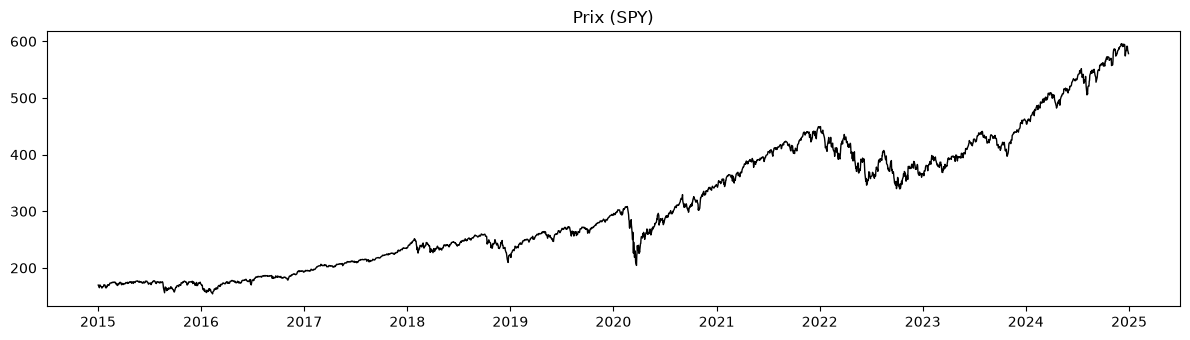

In [ ]:
prices, true_regime = data.load_prices()
source = "synthétique (régimes connus)" if true_regime is not None else "réelles (yfinance)"
print(f"Source : {source} | {len(prices)} jours | {prices.index[0].date()} -> {prices.index[-1].date()}")
print(f"Buy-and-hold sur la période : {prices.iloc[-1]/prices.iloc[0]-1:+.1%}")

fig, ax = plt.subplots(figsize=(12,3.5))
ax.plot(prices.index, prices.values, color="black", lw=1)
ax.set_title(f"Prix ({prices.name})"); plt.tight_layout(); plt.show()

## 2. Couche 1 — HMM (détection probabiliste)

On construit deux *features* d'émission : le **rendement moyen court** (réactivité) et la **volatilité réalisée** (sépare *bear*, très volatil, de *range*, calme). Le HMM apprend trois états gaussiens, qu'on étiquette *bear / range / bull* en les triant par rendement moyen.

Le « **HMM pur** » = régime le plus probable **jour par jour** (argmax de l'émission). C'est notre baseline — et elle *clignote*.

Paramètres d'émission appris :
       rendement_moyen  volatilite
bear          -0.00232     0.02348
range         -0.00034     0.00552
bull           0.00086     0.00333

HMM pur : 208 changements de régime (clignote).


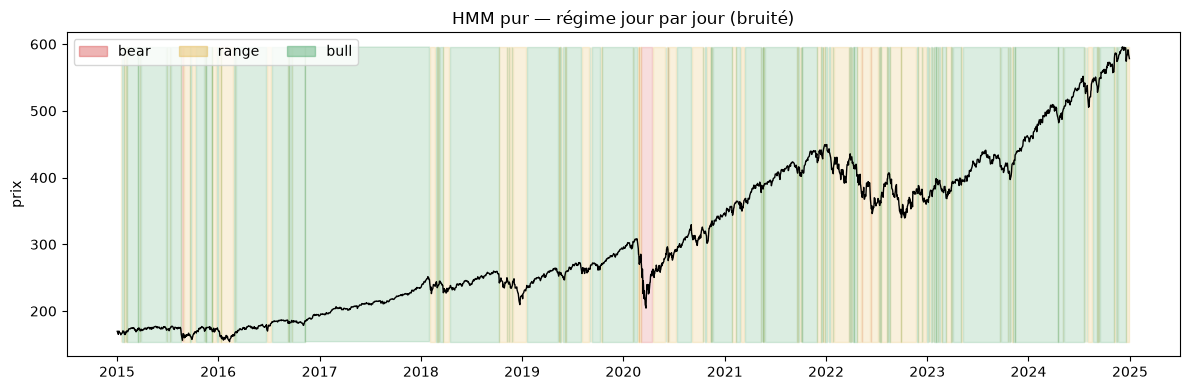

In [ ]:
feats = data.make_features(prices)
model = hmm.fit_hmm(feats)

lab = hmm.label_map(model)
params = pd.DataFrame({
    "rendement_moyen": [model.means_[k][0] for k in range(3)],
    "volatilite":      [np.sqrt(model.covars_[k].diagonal()[1]) for k in range(3)],
}, index=[lab[k] for k in range(3)]).loc[REGIMES]
print("Paramètres d'émission appris :"); print(params.round(5))

proba = hmm.emission_proba(model, feats)
raw   = hmm.naive_regimes(model, feats)
print(f"\nHMM pur : {switches(raw)} changements de régime (clignote).")
plot_regimes(prices, raw, "HMM pur — régime jour par jour (bruité)")

## 3. Couche 2 — Révision des croyances (AGM)

On garde une **croyance** sur le régime courant. À chaque jour, l'évidence du HMM arrive ; on applique une révision de type **AGM** :
- **expansion** (on garde la croyance) si l'évidence est cohérente ou faible — *changement minimal* ;
- **révision** (on change de régime cru) seulement si l'évidence contraire est **forte** (proba ≥ 0.60) **et persistante** (≥ 5 jours) — *succès* sur évidence solide.

Effet : les régimes deviennent nettement plus stables, sans black-box.

Changements de régime : HMM pur 208  ->  +AGM 38 (5.5x plus stable)


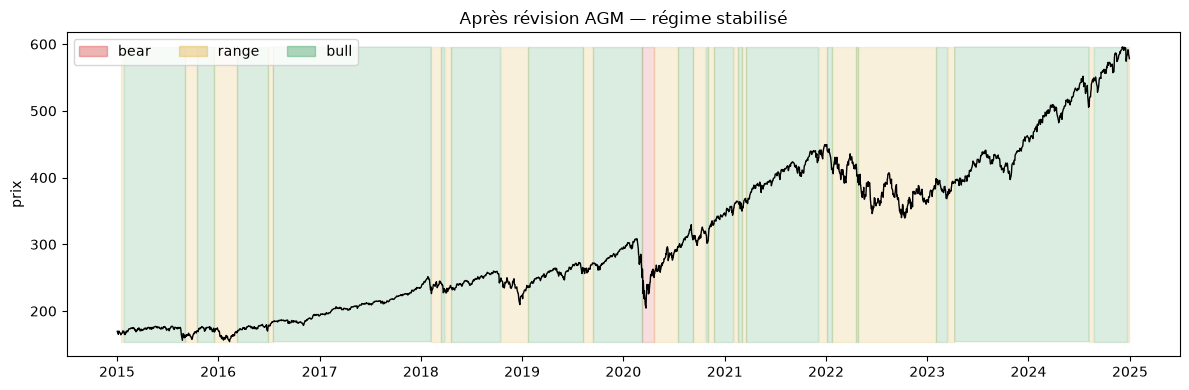

In [4]:
revised = agm.revise_beliefs(proba, conf=0.60, persistence=5)
print(f"Changements de régime : HMM pur {switches(raw)}  ->  +AGM {switches(revised)} "
      f"({switches(raw)/max(switches(revised),1):.1f}x plus stable)")
plot_regimes(prices, revised, "Après révision AGM — régime stabilisé")

## 4. Couche 3 — Transitions qualitatives (logique)

On impose une petite **algèbre de transition** : le *range* est le seul pont entre *bull* et *bear*. Un saut direct *bull → bear* est interdit et corrigé en insérant *range*. C'est une **garantie logique** que le HMM, seul, ne peut pas offrir.

Transitions autorisées :
  bear  -> ['bear', 'range']
  range -> ['bear', 'bull', 'range']
  bull  -> ['bull', 'range']

Transitions illégales — HMM pur : 1 | pipeline : 0 (garanti 0)

Exemple  : ['bull', 'bull', 'bear', 'bear', 'bull', 'range']
corrigé  : ['bull', 'bull', 'range', 'bear', 'range', 'range']  (range inséré)


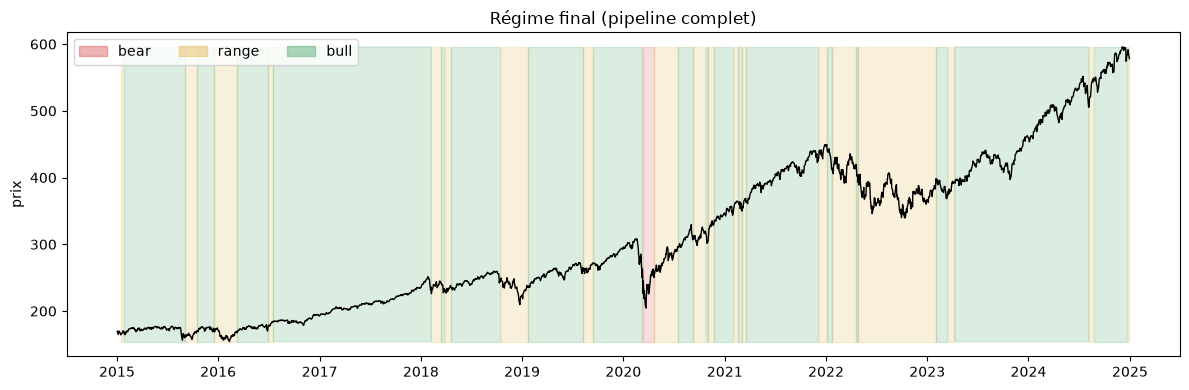

In [ ]:
print("Transitions autorisées :")
for k, v in qualitative.ALLOWED.items():
    print(f"  {k:5s} -> {sorted(v)}")

final = qualitative.enforce_transitions(revised)
print(f"\nTransitions illégales — HMM pur : {qualitative.count_illegal(raw)} | "
      f"pipeline : {qualitative.count_illegal(final)} (garanti 0)")

craft = pd.Series(["bull","bull","bear","bear","bull","range"])
print("\nExemple  :", list(craft.values))
print("corrigé  :", list(qualitative.enforce_transitions(craft).values), " (range inséré)")

plot_regimes(prices, final, "Régime final (pipeline complet)")

## 5. Stratégie multi-régime + backtest

Un actif risqué, exposition selon le régime : **bull → 100 %**, **range → 50 %**, **bear → 0 % (cash)**. Backtest local avec **coûts de transaction (10 bps)** — essentiels : ils pénalisent le sur-trading, ce qui révèle la valeur de la stabilisation.

              rendement_total  sharpe  max_drawdown  trades
HMM pur                 1.495    0.85        -0.194   207.0
pipeline                1.599    0.83        -0.189    38.0
buy_and_hold            2.472    0.80        -0.337     0.0


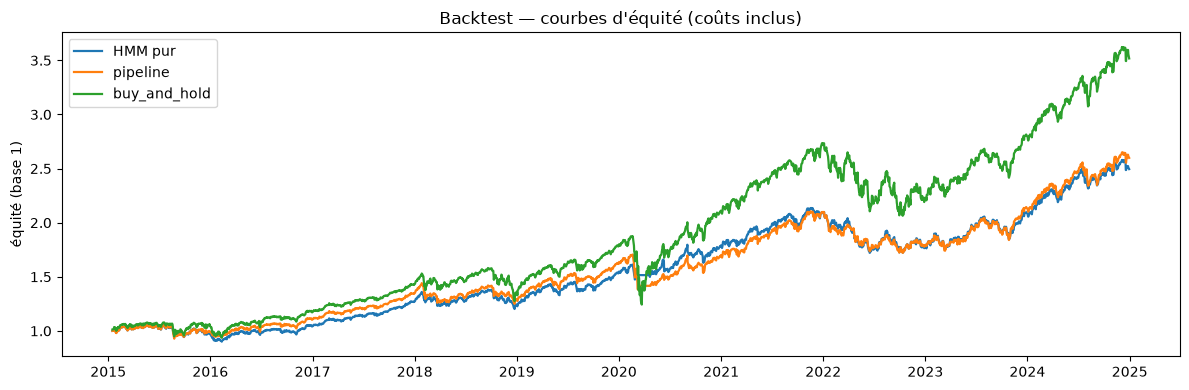

In [6]:
returns = prices.pct_change().reindex(final.index).fillna(0.0)
table, curves = strategy.compare(returns, {"HMM pur": raw, "pipeline": final})
print(table.to_string())

fig, ax = plt.subplots(figsize=(12,4))
for name, eq in curves.items():
    ax.plot(eq.index, eq.values, lw=1.6, label=name)
ax.set_title("Backtest — courbes d'équité (coûts inclus)"); ax.set_ylabel("équité (base 1)")
ax.legend(); plt.tight_layout(); plt.show()

## Ce qu'il faut retenir

- Le **HMM pur** détecte les régimes mais *clignote* (beaucoup de changements, beaucoup de trades).
- La **révision AGM** stabilise fortement le régime (~4× moins de changements) tout en restant **interprétable** (règle explicite : évidence forte et persistante).
- Le **raisonnement qualitatif** garantit des transitions **logiquement cohérentes** (0 saut *bull → bear* direct).
- Au **backtest**, le pipeline trade beaucoup moins que le HMM pur, reste compétitif après coûts, et **réduit fortement le drawdown** par rapport au buy-and-hold.

*Nuance honnête* : sur données bien séparées, l'écart de performance brute entre HMM pur et pipeline est modeste — la vraie valeur des couches symboliques est la **stabilité**, l'**interprétabilité** et la **garantie logique**, pas un gain de rendement spectaculaire. Sur données réelles (yfinance) plus bruitées, l'écart de stabilité et de coûts est en général plus marqué.